> This script is deigned to be used with conda env
> crime_weather_env

ETL pipeline at [combine_crime_ceda_data.py](../1_ETL/combine_crime_ceda_data.py).
Cluser labels generated at [spatial_clustering.ipynb](../2_spatial_clusters/spatial_clustering.ipynb)

# Cluster Context Labels 

This script assigns context labels to 'Leisure' or 'Retail' associated crime zones and removes any clusters that are overly mixed or 'Other'.

Clusters containing the 10% highest proportion of crime types assocatied with either 'Lesiure' or 'Retail' zones are retained as a context defined cluster. This achieved using a 90% quantile metric as the 'Retail' crime type proportion is highly skewed. 

## Import modules

In [64]:
# standard libraries
import os
from pathlib import Path

# other libraries
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

# typers and submodules
from duckdb import DuckDBPyConnection
from pandas import DataFrame


## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [5]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 5;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869,None,None
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065,None,None
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702,289,None,None
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1703,None,None
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347,7123,None,None


This looks good

## Set up crime typology buckets

In [6]:
crime_categories: DataFrame = con.execute(query="""SELECT DISTINCT "Crime type" FROM crimetology_NS_clean""").df()


In [7]:
crime_categories

,Crime type
0,Other crime
1,Criminal damage and arson
2,Anti-social behaviour
3,Burglary
4,Bicycle theft
5,Drugs
6,Other theft
7,Possession of weapons
8,Vehicle crime
9,Public order


In [8]:
leisure_zone_typology: list[str] = ['Anti-social behaviour',
                                  'Criminal damage and arson',
                                  'Public order',
                                  'Vehicle crime',
                                  'Drugs']

leisure_str: str = ", ".join(f"'{c}'" for c in leisure_zone_typology)

In [9]:
commercial_zone_typology: list[str] = ['Other theft', 
                                     'Robbery', 
                                     'Shoplifting']

commercial_str: str = ", ".join(f"'{c}'" for c in commercial_zone_typology)

In [10]:
cluster_classification_query = f"""SELECT "Cluster ID",
                                          "Crime ID",
                                          "Crime type",
                                   CASE 
                                     WHEN "Crime type" IN ({leisure_str}) THEN 'Leisure'
                                     WHEN "Crime type" IN ({commercial_str}) THEN 'Retail'
                                     ELSE 'OTHER'
                                   END AS "Crime Bucket"
                                   FROM crimetology_NS_clean
                                   WHERE "Cluster ID" != -1       -- Ignore noise points
                                   """

In [11]:
event_level_typology: DataFrame = con.execute(query=cluster_classification_query).df()

In [12]:
event_level_typology

,Cluster ID,Crime ID,Crime type,Crime Bucket
0,869,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,Violence and sexual offences,OTHER
1,5065,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,Violence and sexual offences,OTHER
2,289,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,Burglary,OTHER
3,1703,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,Violence and sexual offences,OTHER
4,7123,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,Violence and sexual offences,OTHER
...,...,...,...,...
1254382,3640,df6d8a6101db32b28dd8d47729c4c73db5232f93c6a3e1...,Other theft,Retail
1254383,3529,NO_ID_29c7242b-d14f-4ca6-b6e0-33d8651746c7,Anti-social behaviour,Leisure
1254384,4725,NO_ID_5f8f299e-f3a2-4d68-97b1-ca5758d7f35d,Anti-social behaviour,Leisure
1254385,5065,NO_ID_788aaf02-9509-480e-af3c-50e4401a5083,Anti-social behaviour,Leisure


In [13]:
event_level_typology["Cluster ID"].drop_duplicates()

0           869
1          5065
2           289
3          1703
4          7123
           ... 
1202822    6927
1211083    1794
1216351    4744
1216487    3681
1221602    2943
Name: Cluster ID, Length: 9200, dtype: int32

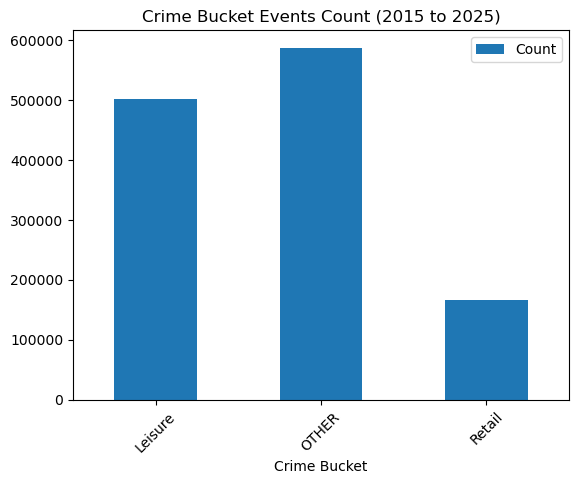

In [14]:
event_level_typology.groupby(by='Crime Bucket').agg(func='count').reset_index()[['Crime Bucket','Cluster ID']].rename(columns = {'Cluster ID':'Count'}).plot.bar(x='Crime Bucket',y='Count',rot=45)
plt.title(label='Crime Bucket Events Count (2015 to 2025)')
plt.show()

## Aggregate to find prevalance of each typology per cluster

In [15]:
# percetage of each zone typology per cluster ID

cluster_zone_prevalence: DataFrame = pd.crosstab(index=event_level_typology['Cluster ID'], columns=event_level_typology['Crime Bucket'],normalize='index')
round(cluster_zone_prevalence,ndigits=2)

Crime Bucket,Leisure,OTHER,Retail
Cluster ID,,,
0,0.27,0.55,0.18
1,0.86,0.00,0.14
2,0.29,0.61,0.10
3,0.40,0.56,0.04
4,0.58,0.42,0.00
...,...,...,...
9195,0.59,0.37,0.04
9196,0.38,0.54,0.08
9197,0.42,0.51,0.07


Now look at the distrubtion of crime types per cluster, to see which crime types are prevalent and how they are distrubted over clusters

<Axes: >

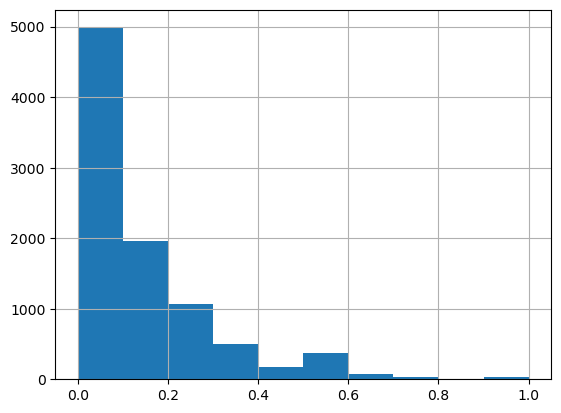

In [16]:
cluster_zone_prevalence['Retail'].hist()

<Axes: >

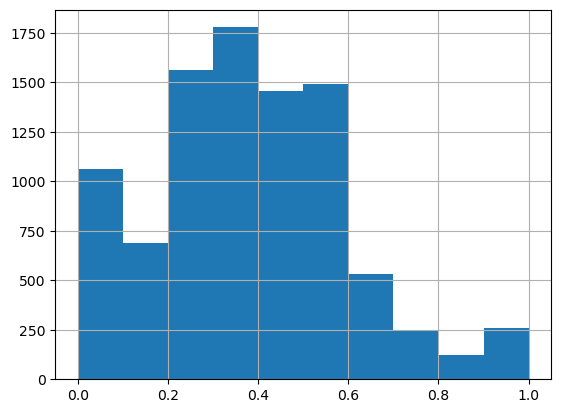

In [17]:
cluster_zone_prevalence['Leisure'].hist()

<Axes: >

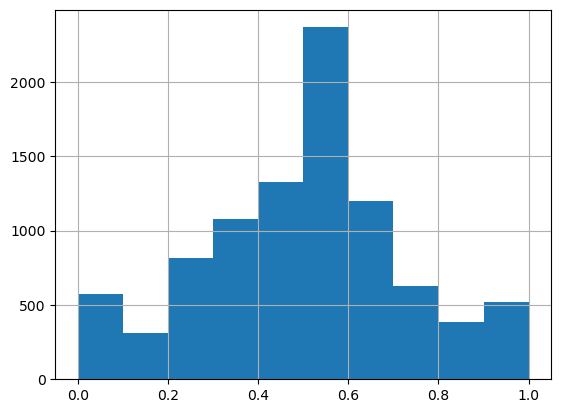

In [18]:
cluster_zone_prevalence['OTHER'].hist()

In [19]:
# check quantiles (dont use mean and std due to skewed retail distru
print(f"Retail Zone 75% Quantile : {round(number=cluster_zone_prevalence['Retail'].quantile(0.75),ndigits=2)}")
print(f"Leisure Zone 75% Quantile : {round(number=cluster_zone_prevalence['Leisure'].quantile(0.75),ndigits=2)}")

Retail Zone 75% Quantile : 0.19
Leisure Zone 75% Quantile : 0.5


In [20]:
# check quantiles (dont use mean and std due to skewed retail distru
print(f"Retail Zone 90% Quantile : {round(number=cluster_zone_prevalence['Retail'].quantile(0.90),ndigits=2)}")
print(f"Leisure Zone 90% Quantile : {round(number=cluster_zone_prevalence['Leisure'].quantile(0.90),ndigits=2)}")

Retail Zone 90% Quantile : 0.33
Leisure Zone 90% Quantile : 0.67


**Observations**

1. Retail associated crime types are rarer, clusters typically contain far less than 20% of events with this labelling. The distrubution is highly skewed. This shows us that even if clusters contain only 30% of this crime type then it is still in the top 10% highest retail associated crime zones. 
1. The other two are more Guassian in nature. Meaning that there is a level of consistent background occurance of these crime types across the majority of clusters. 


These distrubtions do makes sense as, for example, the leisure typology contains crimes such as ASB and Criminal damage, which could happen in retail zones too, whereas crimes such as shoplifting are only able to happen in retail zones.

_Idea_:

Use the 90% quantile to isolate the top 10% of clusters associated with Lesiure or Retail crime types. 

 - In an attempt to pull true 'Leisure' zones via a cluster having >67% of lesiure associated crime typologies
 - To isolate reatil/business clusters with the rarer occuring 'Retail' crime types allow a lower threshold of >33%

## Cluster zone typing by percentiles

In [21]:
quantile_bound: float = 0.90
cluster_zone_prevalence['is_leisure_zone'] = (cluster_zone_prevalence['Leisure'] > cluster_zone_prevalence['Leisure'].quantile(quantile_bound))
cluster_zone_prevalence['is_retail_zone'] = (cluster_zone_prevalence['Retail'] > cluster_zone_prevalence['Retail'].quantile(quantile_bound))

In [22]:
cluster_zone_prevalence

Crime Bucket,Leisure,OTHER,Retail,is_leisure_zone,is_retail_zone
Cluster ID,,,,,
0,0.272727,0.545455,0.181818,False,False
1,0.857143,0.000000,0.142857,True,False
2,0.290323,0.612903,0.096774,False,False
3,0.395105,0.564685,0.040210,False,False
4,0.583333,0.416667,0.000000,False,False
...,...,...,...,...,...
9195,0.588235,0.372549,0.039216,False,False
9196,0.384615,0.538462,0.076923,False,False
9197,0.419263,0.509915,0.070822,False,False


In [23]:
# check to make sure a cluster isnt in the top 10% for both retail and lesiure types

overlap: DataFrame = cluster_zone_prevalence[(cluster_zone_prevalence['is_leisure_zone'] == 1) & (cluster_zone_prevalence['is_retail_zone'] == 1)]
if len(overlap) > 0:
    print("Overlap Exists, proceed with caution. ")
    

In [24]:
## Now assign the cluster topology label

cluster_label_conditions: list = [(cluster_zone_prevalence['is_retail_zone'] == True) & (cluster_zone_prevalence['is_leisure_zone'] == False),
                                  (cluster_zone_prevalence['is_retail_zone'] == False) & (cluster_zone_prevalence['is_leisure_zone'] == True)]

labels: list[str] = ['Retail','Leisure']

cluster_zone_prevalence['Cluster Label'] = np.select(condlist=cluster_label_conditions,
                                                     choicelist=labels, 
                                                     default='Other')

cluster_zone_prevalence

Crime Bucket,Leisure,OTHER,Retail,is_leisure_zone,is_retail_zone,Cluster Label
Cluster ID,,,,,,
0,0.272727,0.545455,0.181818,False,False,Other
1,0.857143,0.000000,0.142857,True,False,Leisure
2,0.290323,0.612903,0.096774,False,False,Other
3,0.395105,0.564685,0.040210,False,False,Other
4,0.583333,0.416667,0.000000,False,False,Other
...,...,...,...,...,...,...
9195,0.588235,0.372549,0.039216,False,False,Other
9196,0.384615,0.538462,0.076923,False,False,Other
9197,0.419263,0.509915,0.070822,False,False,Other


In [25]:
# sanity checks
print(f""" Leisure labelled clusters total is {(cluster_zone_prevalence["Cluster Label"]=="Leisure").sum()} """ )
print(f""" Retail labelled clusters total is {(cluster_zone_prevalence["Cluster Label"]=="Retail").sum()} """ )
print(f""" Other labelled clusters total is {(cluster_zone_prevalence["Cluster Label"]=="Other").sum()} """ )

 Leisure labelled clusters total is 688 
 Retail labelled clusters total is 785 
 Other labelled clusters total is 7727 


Note: Suprisingly there are more retail clusters isolated than leisure clusters. Final samples will depend on how many crime events occur at each cluster type though, so if one cluster type has a higher density than the other the distrubtions of leisure to retail may/will still change. Currently samples look reasonable though.  

## Map cluster typologies back on to crime level data

In [26]:
label_map = cluster_zone_prevalence['Cluster Label']
label_map

Cluster ID
0         Other
1       Leisure
2         Other
3         Other
4         Other
         ...   
9195      Other
9196      Other
9197      Other
9198      Other
9199      Other
Name: Cluster Label, Length: 9200, dtype: object

In [27]:
event_level_typology['Cluster Label'] = event_level_typology['Cluster ID'].map(label_map)

In [28]:
event_level_typology

,Cluster ID,Crime ID,Crime type,Crime Bucket,Cluster Label
0,869,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,Violence and sexual offences,OTHER,Other
1,5065,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,Violence and sexual offences,OTHER,Other
2,289,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,Burglary,OTHER,Other
3,1703,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,Violence and sexual offences,OTHER,Other
4,7123,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,Violence and sexual offences,OTHER,Other
...,...,...,...,...,...
1254382,3640,df6d8a6101db32b28dd8d47729c4c73db5232f93c6a3e1...,Other theft,Retail,Other
1254383,3529,NO_ID_29c7242b-d14f-4ca6-b6e0-33d8651746c7,Anti-social behaviour,Leisure,Other
1254384,4725,NO_ID_5f8f299e-f3a2-4d68-97b1-ca5758d7f35d,Anti-social behaviour,Leisure,Other
1254385,5065,NO_ID_788aaf02-9509-480e-af3c-50e4401a5083,Anti-social behaviour,Leisure,Other


Update the duckdb table

In [29]:
con.register(view_name="labels_df", python_object=event_level_typology)

In [36]:
con.execute(query="""SELECT * FROM labels_df WHERE "Cluster Label" IN ('Leisure','Retail') LIMIT 30;""").df()

,Cluster ID,Crime ID,Crime type,Crime Bucket,Cluster Label
0,2034,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,Criminal damage and arson,Leisure,Leisure
1,2524,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,Violence and sexual offences,OTHER,Retail
2,3219,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,Violence and sexual offences,OTHER,Leisure
3,1690,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,Shoplifting,Retail,Retail
4,8233,08059176f2ca15ed52158c38966df742603f12105e5942...,Other theft,Retail,Retail
5,2557,daccabb2e8bdaf69f57060e7e79d0c68ed24ebbaacd457...,Burglary,OTHER,Retail
6,6348,35d17056e08f3172641320717c171a515aaf29e3782965...,Shoplifting,Retail,Retail
7,5464,b1efc98ae39fa35de35b16092769871c7d4da170302700...,Shoplifting,Retail,Retail
8,9070,4be2f2cef0a29551861379f39b3d32bbbdd360762d220f...,Shoplifting,Retail,Retail
9,1066,9971d0ffadefd4f8d137469e799882dce56e08ce583d67...,Other theft,Retail,Retail


In [30]:
add_columns_query = """ALTER TABLE crimetology_NS_clean 
                           ADD COLUMN IF NOT EXISTS "Crime Bucket" VARCHAR;
                      ALTER TABLE crimetology_NS_clean
                           ADD COLUMN IF NOT EXISTS "Cluster Label" VARCHAR;
                    """

con.execute(query=add_columns_query)

In [31]:
con.execute(query="""SELECT * FROM crimetology_NS_clean LIMIT 5;""").df()

,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869,None,None
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065,None,None
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702,289,None,None
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1703,None,None
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347,7123,None,None


Add the cluster typology labels - being very cautious as it is a larger datatable and I dont want to have to redo it. 

In [41]:
add_cluster_typology_query = """UPDATE crimetology_NS_clean
                        SET "Cluster Label" = labels_df."Cluster Label"
                        FROM labels_df
                        WHERE  crimetology_NS_clean."Crime ID" = labels_df."Crime ID";
                        """

In [43]:
con.execute(query="BEGIN TRANSACTION;")
con.execute(query=add_cluster_typology_query)

In [44]:
con.execute(query="""SELECT * FROM crimetology_NS_clean LIMIT 5;""").df()

,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869,None,Other
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065,None,Other
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702,289,None,Other
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1703,None,Other
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347,7123,None,Other


In [45]:
con.execute(query="COMMIT;")

Add the crime typology labels - being very cautious as it is a larger datatable and I dont want to have to redo it. 

In [46]:
add_crime_typology_query = """UPDATE crimetology_NS_clean
                              SET "Crime Bucket" = labels_df."Crime Bucket"
                              FROM labels_df
                              WHERE  crimetology_NS_clean."Crime ID" = labels_df."Crime ID";
                           """

In [47]:
con.execute(query="BEGIN TRANSACTION;")
con.execute(query=add_crime_typology_query)

In [50]:
#con.execute(query="""SELECT * FROM crimetology_NS_clean LIMIT 35;""").df()

In [51]:
#con.execute(query="ROLLBACK;")

#All looks good
con.execute(query="COMMIT;")

Have a look at the data for a final sense check

In [56]:
con.execute(query="""SELECT * FROM crimetology_NS_clean WHERE "Cluster Label" IN ('Retail') LIMIT 10;""").df()

,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,2020-01,0.866601,52.839371,Violence and sexual offences,9.033701,6.224151,10.053925,69.866371,0.045262,3.584216,61.193233,88.757492,4.896767,2524,OTHER,Retail
1,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,2020-01,0.690857,52.252783,Shoplifting,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1690,Retail,Retail
2,08059176f2ca15ed52158c38966df742603f12105e5942...,2020-01,1.508512,52.353431,Other theft,9.297161,6.224165,11.236046,55.952740,0.061154,3.368905,45.252079,89.673691,4.178386,8233,Retail,Retail
3,daccabb2e8bdaf69f57060e7e79d0c68ed24ebbaacd457...,2020-01,0.870483,52.839691,Burglary,9.033701,6.224151,10.053925,69.866371,0.045262,3.584216,61.193233,88.757492,4.896767,2557,OTHER,Retail
4,35d17056e08f3172641320717c171a515aaf29e3782965...,2020-01,1.288497,52.605340,Shoplifting,9.234637,6.399334,12.503027,57.661350,0.000000,3.582139,52.317886,88.142769,4.498458,6348,Retail,Retail
5,b1efc98ae39fa35de35b16092769871c7d4da170302700...,2020-01,1.209914,52.645576,Shoplifting,9.102405,6.293329,11.127260,58.874779,0.000000,3.516935,57.816380,87.769524,4.948392,5464,Retail,Retail
6,4be2f2cef0a29551861379f39b3d32bbbdd360762d220f...,2020-01,1.712651,52.596919,Shoplifting,9.426891,6.667203,9.887568,61.054985,0.000000,3.979508,43.952835,88.471741,6.102756,9070,Retail,Retail
7,9971d0ffadefd4f8d137469e799882dce56e08ce583d67...,2020-01,0.534945,52.337356,Other theft,9.549690,6.803720,8.292417,57.915279,0.034745,4.044361,46.291641,88.789337,4.348133,1066,Retail,Retail
8,6499ede2e7bf7a78438c4427af69bc7223f185c8d7788d...,2020-01,1.277346,52.066033,Shoplifting,9.228567,6.640045,12.866413,55.665123,0.000000,4.060223,41.133335,89.588570,4.167727,6608,Retail,Retail
9,f24e2dfd878da34a7e661f76d7eaed5d63ab4f9d09c047...,2020-01,1.277586,52.595138,Violence and sexual offences,9.205774,6.368842,11.768906,57.773922,0.000000,3.561786,50.496254,88.417023,4.508505,6246,OTHER,Retail


In [55]:
con.execute(query="""SELECT * FROM crimetology_NS_clean WHERE "Cluster Label" IN ('Leisure') LIMIT 10;""").df()

,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,2020-01,0.748588,52.199671,Criminal damage and arson,8.992604,6.298035,9.822821,61.205822,0.182533,3.622673,54.864017,89.899658,4.399464,2034,Leisure,Leisure
1,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,2020-01,0.954042,52.682650,Violence and sexual offences,9.201315,6.366257,8.425074,62.469185,0.041273,3.607168,63.139992,88.917358,5.196404,3219,OTHER,Leisure
2,751cceb3d6298bc266eeca1b887a3836734243e835c7fc...,2020-01,0.954042,52.682650,Vehicle crime,9.201315,6.366257,8.425074,62.469185,0.041273,3.607168,63.139992,88.917358,5.196404,3219,Leisure,Leisure
3,bbeeecfaa178856326107f9e4082ba6bb330ddd2a923e4...,2020-01,0.743652,52.427745,Criminal damage and arson,9.372630,6.158432,9.952010,55.896851,0.057323,3.322031,51.558739,89.147903,5.153960,1936,Leisure,Leisure
4,NO_ID_0667cd8e-4962-4f82-bee7-1c2cc388e056,2020-01,0.597796,52.327412,Anti-social behaviour,9.416149,6.691670,8.028224,59.339790,0.042590,3.997586,46.515572,89.343513,4.412496,1305,Leisure,Leisure
5,968ea1de1b8e23713d2b0381097870fc338d873d9e5cbe...,2020-01,1.499965,52.239500,Public order,9.472532,6.346707,12.125896,56.460575,0.050218,3.399856,45.662125,89.856918,4.304664,8236,Leisure,Leisure
6,NO_ID_e9582c97-604b-4222-869c-8e8796426c24,2020-01,1.266371,52.024650,Anti-social behaviour,9.295247,6.783341,12.321029,56.024811,0.000000,4.257624,36.110455,89.471504,4.141700,6540,Leisure,Leisure
7,ae74e0e8ff6e6a7bfcdf4facb733a231c3ff6b570ab7c1...,2020-01,0.964273,52.655659,Vehicle crime,9.217144,6.393272,8.510882,61.510841,0.047778,3.635024,63.175076,88.977234,5.067014,3304,Leisure,Leisure
8,NO_ID_ca35603e-607d-477e-9b02-064525a595d0,2020-01,1.388541,52.817127,Anti-social behaviour,9.301908,6.333391,6.658817,70.480736,0.000000,3.517998,51.549873,87.792992,5.681309,7094,Leisure,Leisure
9,93f8fcbda8d1bf6809509bd8a4f5472a530f49150c8a8e...,2020-01,0.954042,52.682650,Vehicle crime,9.201315,6.366257,8.425074,62.469185,0.041273,3.607168,63.139992,88.917358,5.196404,3219,Leisure,Leisure


## Plot of Leisure and Retail clusters

In [57]:
final_check: DataFrame = con.execute(query="""SELECT Longitude,
                                                     Latitude,
                                                     "Cluster ID",
                                                     "Cluster Label"
                                             FROM crimetology_NS_clean 
                                             WHERE "Cluster Label" IN ('Leisure','Retail');""").df()

In [58]:
final_check

,Longitude,Latitude,Cluster ID,Cluster Label
0,0.748588,52.199671,2034,Leisure
1,0.866601,52.839371,2524,Retail
2,0.954042,52.682650,3219,Leisure
3,0.690857,52.252783,1690,Retail
4,1.508512,52.353431,8233,Retail
...,...,...,...,...
43929,1.268329,52.626296,6132,Leisure
43930,1.181375,52.654090,5197,Retail
43931,1.181375,52.654090,5197,Retail
43932,1.181375,52.654090,5197,Retail


In [63]:
## plotly cant cope with original data size. 
plot_data: DataFrame = final_check.groupby(by="Cluster ID").agg(label=("Cluster Label", 'first'),lat=("Latitude", 'mean'),lon=("Longitude", 'mean'),point_count=("Cluster ID", 'count')).reset_index()
plot_data

,Cluster ID,label,lat,lon,point_count
0,1,Leisure,52.771041,0.303858,7
1,18,Leisure,52.581285,0.307737,13
2,26,Leisure,52.735393,0.319354,15
3,31,Leisure,52.456754,0.308334,4
4,36,Leisure,52.686885,0.323440,7
...,...,...,...,...,...
1468,9180,Retail,52.395193,1.724629,2
1469,9188,Leisure,52.505280,1.741472,2
1470,9190,Retail,52.507786,1.742422,2
1471,9193,Leisure,52.499991,1.751188,37


In [79]:
color_map: dict[str, str] = {'Retail': '#FFD700',
                             'Leisure': '#1F77B4'}

fig = px.scatter_map(data_frame=plot_data,
                            lat='lat',
                            lon='lon',
                            size='point_count',
                            color='label',
                            color_discrete_map=color_map,
                            zoom=7,
                            size_max=50,
                            title='Norfolk and Suffolk Crime Location Cluster Types (2015-2025)')
                            
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.update_yaxes(scaleanchor="x",scaleratio=1)
fig.update_layout(width=800, height=800)
fig.show()

In [80]:
con.close()